Setup & Data Load

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data from previous notebook
df = pd.read_csv('data/online_retail_II.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(
    f"CLEANED DATA LOADED\n"
    f"Rows: {len(df):,}\n"
    f"Customers: {df['Customer ID'].nunique():,}"
)

CLEANED DATA LOADED
Rows: 220,626
Customers: 5,414


RFM Metrics Calculate

In [9]:
# Reference date = 1 day after last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference Date: {reference_date.date()}")

# Calculate RFM for each customer
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalAmount', 'sum')
).reset_index()

print(f"\nRFM CALCULATED FOR {len(rfm):,} CUSTOMERS")
print(f"\nRFM Summary:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

Reference Date: 2011-12-10

RFM CALCULATED FOR 5,414 CUSTOMERS

RFM Summary:
       Recency  Frequency   Monetary
count  5414.00    5414.00    5414.00
mean    203.73       5.86    1971.39
std     209.45      11.44   12150.34
min       1.00       1.00      17.70
25%      26.00       1.00     154.31
50%     101.50       3.00     415.96
75%     380.75       6.00    1247.46
max     739.00     376.00  507514.43


RFM Score

In [10]:
# Score 1-5 (5 = best)
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=5, labels=[1,2,3,4,5])

# Combined RFM Score
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print("RFM SCORES ASSIGNED!")
print(f"\nRFM Score Range: {rfm['RFM_Score'].min()} to {rfm['RFM_Score'].max()}")
print(f"\nScore Distribution:\n")
print(rfm['RFM_Score'].value_counts().sort_index())

RFM SCORES ASSIGNED!

RFM Score Range: 3 to 15

Score Distribution:

RFM_Score
3     256
4     452
5     452
6     424
7     470
8     449
9     472
10    451
11    441
12    394
13    381
14    367
15    405
Name: count, dtype: int64


Customer Segment

In [11]:
def assign_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'
    elif r <= 2 and f <= 2:
        return 'Lost Customers'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print("CUSTOMER SEGMENTS ASSIGNED!")
print(f"\nSegment Distribution:")
segment_counts = rfm['Segment'].value_counts()
for segment, count in segment_counts.items():
    pct = count/len(rfm)*100
    print(f"  {segment:<25} : {count:>4} customers ({pct:.1f}%)")

CUSTOMER SEGMENTS ASSIGNED!

Segment Distribution:
  Lost Customers            : 1392 customers (25.7%)
  Champions                 : 1119 customers (20.7%)
  Loyal Customers           : 1024 customers (18.9%)
  At Risk                   :  573 customers (10.6%)
  Needs Attention           :  490 customers (9.1%)
  New Customers             :  423 customers (7.8%)
  Potential Loyalists       :  393 customers (7.3%)


RFM Visualization

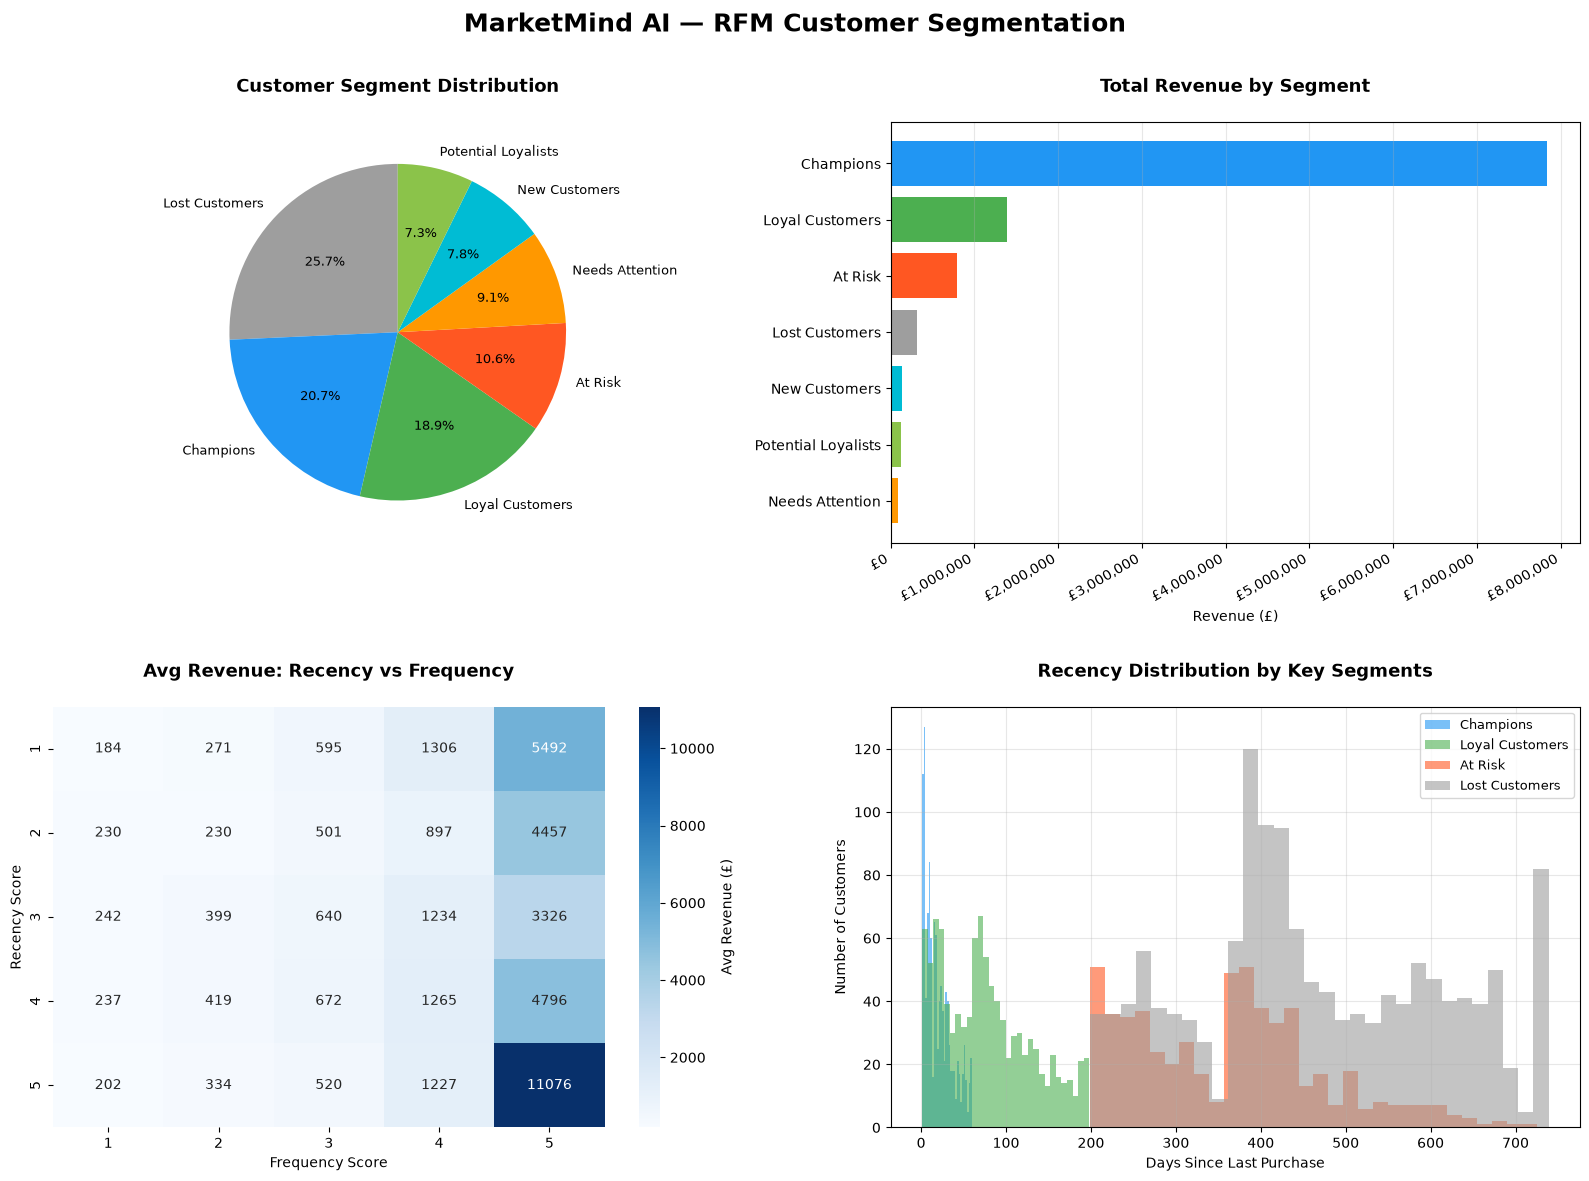

RFM Analysis Chart saved!


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('MarketMind AI — RFM Customer Segmentation\n', fontsize=18, fontweight='bold')

# Color palette for segments
colors = {
    'Champions': '#2196F3',
    'Loyal Customers': '#4CAF50', 
    'Potential Loyalists': '#8BC34A',
    'New Customers': '#00BCD4',
    'Needs Attention': '#FF9800',
    'At Risk': '#FF5722',
    'Cannot Lose Them': '#9C27B0',
    'Lost Customers': '#9E9E9E'
}

segment_counts = rfm['Segment'].value_counts()
chart_colors = [colors.get(s, '#90CAF9') for s in segment_counts.index]

# Chart 1: Segment Distribution (Pie)
axes[0,0].pie(segment_counts.values, labels=segment_counts.index,
              colors=chart_colors, autopct='%1.1f%%', startangle=90,
              textprops={'fontsize': 9})
axes[0,0].set_title('Customer Segment Distribution\n', fontsize=13, fontweight='bold')

# Chart 2: Revenue by Segment (Bar)
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=True)
bar_colors = [colors.get(s, '#90CAF9') for s in segment_revenue.index]
axes[0,1].barh(segment_revenue.index, segment_revenue.values, color=bar_colors)
axes[0,1].set_title('Total Revenue by Segment\n', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Revenue (£)')
axes[0,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
axes[0,1].grid(True, alpha=0.3, axis='x')
plt.setp(axes[0,1].get_xticklabels(), rotation=30, ha='right')

# Chart 3: RFM Score Heatmap
rfm_pivot = rfm.groupby(['R_Score', 'F_Score'])['Monetary'].mean().unstack(fill_value=0)
sns.heatmap(rfm_pivot, ax=axes[1,0], cmap='Blues', fmt='.0f', annot=True,
            cbar_kws={'label': 'Avg Revenue (£)'})
axes[1,0].set_title('\nAvg Revenue: Recency vs Frequency\n', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Frequency Score')
axes[1,0].set_ylabel('Recency Score')

# Chart 4: Recency Distribution by Segment
top_segments = ['Champions', 'Loyal Customers', 'At Risk', 'Lost Customers']
rfm_filtered = rfm[rfm['Segment'].isin(top_segments)]
for segment in top_segments:
    data = rfm_filtered[rfm_filtered['Segment'] == segment]['Recency']
    axes[1,1].hist(data, alpha=0.6, label=segment, bins=30, 
                   color=colors.get(segment))
axes[1,1].set_title('\nRecency Distribution by Key Segments\n', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Days Since Last Purchase')
axes[1,1].set_ylabel('Number of Customers')
axes[1,1].legend(fontsize=9)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("RFM Analysis Chart saved!")

K-Means Clustering

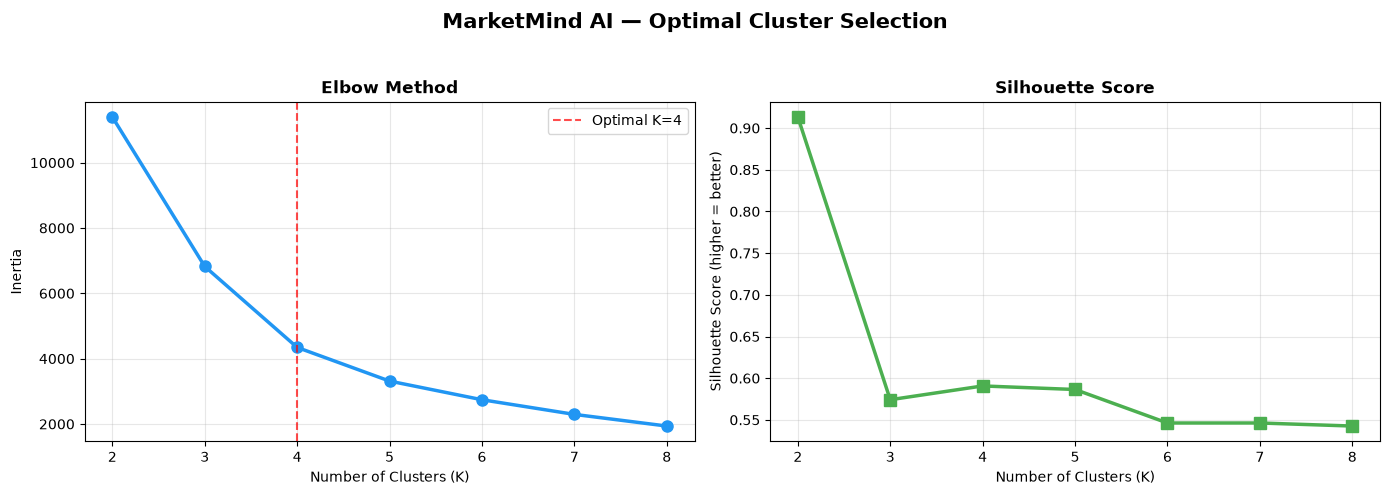

ELBOW METHOD COMPLETE!
   Best K by Silhouette Score: 2


In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Prepare data for clustering
X = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal K using Elbow Method
inertia = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MarketMind AI — Optimal Cluster Selection\n', fontsize=15, fontweight='bold')

axes[0].plot(K_range, inertia, marker='o', color='#2196F3', linewidth=2.5, markersize=8)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Optimal K=4')
axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, marker='s', color='#4CAF50', linewidth=2.5, markersize=8)
axes[1].set_title('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"ELBOW METHOD COMPLETE!")
print(f"   Best K by Silhouette Score: {best_k}")

Final Clustering

In [17]:
# Apply K-Means with optimal clusters
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

# Analyze each cluster
cluster_summary = rfm.groupby('Cluster').agg(
    Customers     = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency', 'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary', 'mean'),
    Total_Revenue = ('Monetary', 'sum')
).round(1)

# Sort by Avg_Monetary to assign labels correctly
sorted_clusters = cluster_summary['Avg_Monetary'].sort_values()

label_map = {
    sorted_clusters.index[0]: 'Churned',
    sorted_clusters.index[1]: 'Active-Regular',
    sorted_clusters.index[2]: 'VIP',
    sorted_clusters.index[3]: 'Ultra-High-Value'
}

rfm['Cluster_Label'] = rfm['Cluster'].map(label_map)

print("K-MEANS CLUSTERING COMPLETE — LABELS FIXED!")
print(f"\nCluster Summary:")
print(cluster_summary.to_string())
print(f"\nCorrected Cluster Labels:")
for k, v in label_map.items():
    c = cluster_summary.loc[k]
    print(f"  Cluster {k} → {v:<20} | {int(c['Customers']):>4} customers | Avg £{c['Avg_Monetary']:>10,.0f}")

K-MEANS CLUSTERING COMPLETE — LABELS FIXED!

Cluster Summary:
         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue
Cluster                                                                    
0             1854        463.3            2.1         424.7       787428.8
1               61         18.1           69.9       42129.2      2569883.3
2             3495         69.5            6.5        1674.0      5850667.7
3                4          3.5          199.2      366275.7      1465102.9

Corrected Cluster Labels:
  Cluster 0 → Churned              | 1854 customers | Avg £       425
  Cluster 2 → Active-Regular       | 3495 customers | Avg £     1,674
  Cluster 1 → VIP                  |   61 customers | Avg £    42,129
  Cluster 3 → Ultra-High-Value     |    4 customers | Avg £   366,276


Clustering Visualization

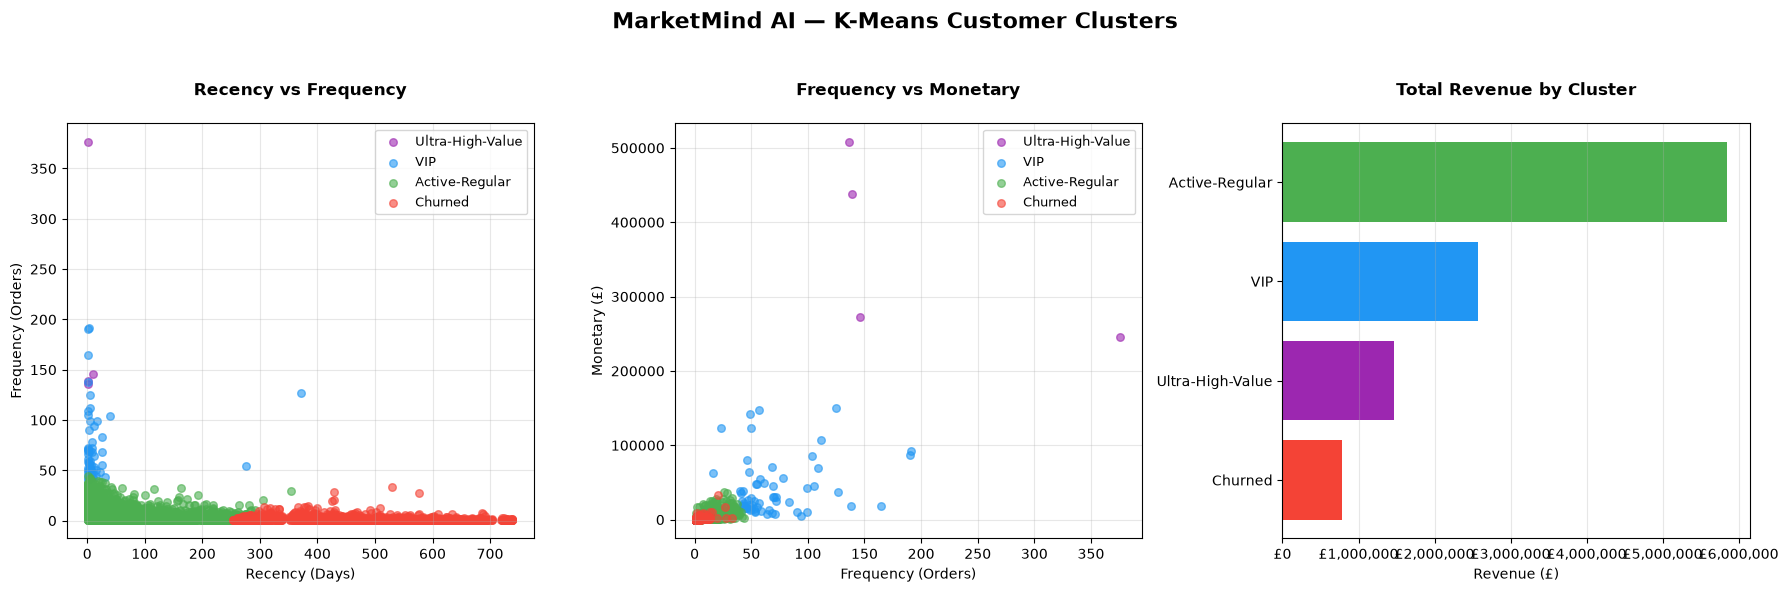

K-Means Chart Fixed & Saved!


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('MarketMind AI — K-Means Customer Clusters\n', fontsize=16, fontweight='bold')

# Updated colors matching correct labels
cluster_colors = {
    'Ultra-High-Value': '#9C27B0',
    'VIP':              '#2196F3',
    'Active-Regular':   '#4CAF50',
    'Churned':          '#F44336'
}

# Chart 1: Recency vs Frequency
for label, color in cluster_colors.items():
    mask = rfm['Cluster_Label'] == label
    axes[0].scatter(rfm[mask]['Recency'], rfm[mask]['Frequency'],
                   c=color, label=label, alpha=0.6, s=30)
axes[0].set_title('Recency vs Frequency\n', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Recency (Days)')
axes[0].set_ylabel('Frequency (Orders)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Chart 2: Frequency vs Monetary
for label, color in cluster_colors.items():
    mask = rfm['Cluster_Label'] == label
    axes[1].scatter(rfm[mask]['Frequency'], rfm[mask]['Monetary'],
                   c=color, label=label, alpha=0.6, s=30)
axes[1].set_title('Frequency vs Monetary\n', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency (Orders)')
axes[1].set_ylabel('Monetary (£)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Chart 3: Revenue by Cluster
cluster_rev = rfm.groupby('Cluster_Label')['Monetary'].sum().sort_values(ascending=True)
bar_colors = [cluster_colors.get(l, '#90CAF9') for l in cluster_rev.index]
axes[2].barh(cluster_rev.index, cluster_rev.values, color=bar_colors)
axes[2].set_title('Total Revenue by Cluster\n', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Revenue (£)')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("K-Means Chart Fixed & Saved!")